# Phase 4 -- Multi-seed variance check (hybrid quantum CNN)

Phase 3's two OFAT ablation sweeps each used a single seed, so the project baseline (4 qubits, 2 layers) not winning either sweep couldn't be trusted -- it might be a real architectural effect, or it might just be which random initialization got lucky. This notebook re-runs the sweep extremes across 5 `training_seed` values (42 reused from Phase 3, plus 43/44/45/46 newly trained) with `data_seed` fixed at 42 throughout, so only weight initialization and batch shuffling vary -- never which images were subsampled.

- **Qubit sweep extremes:** `qubits_2`, `qubits_8`
- **Depth sweep extremes:** `depth_1`, `depth_2` (the project baseline, and its closest Phase 3 competitor)

It loads the per-seed and summary results, plots accuracy variance per config with individual seeds overlaid, checks whether the mean +/- std ranges for each competing pair overlap, and inspects the one seed that behaved very differently from its siblings.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
import yaml
from IPython.display import Image, display

project_root = Path.cwd().resolve()
if not (project_root / 'results').exists():
    project_root = Path('d:/Dissertation/qcnn-dissertation').resolve()

sys.path.insert(0, str(project_root))

from src.data.dataset import get_dataloaders
from src.models.hybrid_cnn import HybridCNN
from src.training.engine import evaluate
from src.training.metrics import confusion_matrix_fig
from src.utils.plotting import plot_comparison, plot_multiseed_variance

print('Imports OK')
print(f'Project root: {project_root}')

Imports OK
Project root: D:\Dissertation\qcnn-dissertation


## Configuration

Four groups, each with 5 seed points: `training_seed=42` reuses the existing Phase 3 ablation result (not retrained), `training_seed` in {43, 44, 45, 46} are the new Phase 4 runs under `configs/multiseed/` / `results/multiseed/`.

In [2]:
def load_config(config_path):
    with open(config_path, 'r', encoding='utf-8') as f:
        config = yaml.safe_load(f)
    config['dataset']['data_root'] = str(project_root / 'data')
    return config

GROUPS = ['qubits_2', 'qubits_8', 'depth_1', 'depth_2']
NEW_SEEDS = [43, 44, 45, 46]

def run_specs(group):
    specs = [{
        'label': f'{group}_seed42',
        'group': group,
        'training_seed': 42,
        'reused': True,
        'config': project_root / 'configs' / 'ablation' / f'{group}.yaml',
        'results_dir': project_root / 'results' / 'ablation' / group,
    }]
    for seed in NEW_SEEDS:
        specs.append({
            'label': f'{group}_seed{seed}',
            'group': group,
            'training_seed': seed,
            'reused': False,
            'config': project_root / 'configs' / 'multiseed' / f'{group}_seed{seed}.yaml',
            'results_dir': project_root / 'results' / 'multiseed' / f'{group}_seed{seed}',
        })
    return specs

ALL_RUNS = [spec for group in GROUPS for spec in run_specs(group)]

SUMMARY_CSV = project_root / 'results' / 'multiseed' / 'summary.csv'
PER_SEED_CSV = project_root / 'results' / 'multiseed' / 'per_seed_metrics.csv'

print(f'{len(ALL_RUNS)} runs across {len(GROUPS)} groups (5 seeds each)')
for spec in ALL_RUNS:
    tag = ' (reused from Phase 3)' if spec['reused'] else ''
    print(f"  {spec['label']}: {spec['config'].name}{tag}")

20 runs across 4 groups (5 seeds each)
  qubits_2_seed42: qubits_2.yaml (reused from Phase 3)
  qubits_2_seed43: qubits_2_seed43.yaml
  qubits_2_seed44: qubits_2_seed44.yaml
  qubits_2_seed45: qubits_2_seed45.yaml
  qubits_2_seed46: qubits_2_seed46.yaml
  qubits_8_seed42: qubits_8.yaml (reused from Phase 3)
  qubits_8_seed43: qubits_8_seed43.yaml
  qubits_8_seed44: qubits_8_seed44.yaml
  qubits_8_seed45: qubits_8_seed45.yaml
  qubits_8_seed46: qubits_8_seed46.yaml
  depth_1_seed42: depth_1.yaml (reused from Phase 3)
  depth_1_seed43: depth_1_seed43.yaml
  depth_1_seed44: depth_1_seed44.yaml
  depth_1_seed45: depth_1_seed45.yaml
  depth_1_seed46: depth_1_seed46.yaml
  depth_2_seed42: depth_2.yaml (reused from Phase 3)
  depth_2_seed43: depth_2_seed43.yaml
  depth_2_seed44: depth_2_seed44.yaml
  depth_2_seed45: depth_2_seed45.yaml
  depth_2_seed46: depth_2_seed46.yaml


## 1. Multiseed configuration summary

Confirms every group/seed config shares the same subset `dataset` block and `data_seed=42`, and that only `training_seed` and the swept model parameter (`n_qubits` or `n_qlayers`) differ within a group.

In [3]:
rows = []
for spec in ALL_RUNS:
    if not spec['config'].exists():
        continue
    cfg = load_config(spec['config'])
    rows.append({
        'run': spec['label'],
        'group': spec['group'],
        'n_qubits': cfg['model'].get('n_qubits'),
        'n_qlayers': cfg['model'].get('n_qlayers'),
        'epochs': cfg['training'].get('epochs'),
        'data_seed': cfg.get('data_seed'),
        'training_seed': cfg.get('training_seed'),
        'reused': spec['reused'],
    })

config_summary_df = pd.DataFrame(rows)
display(config_summary_df)

,run,group,n_qubits,n_qlayers,epochs,data_seed,training_seed,reused
0,qubits_2_seed42,qubits_2,2,2,15,42,42,True
1,qubits_2_seed43,qubits_2,2,2,15,42,43,False
2,qubits_2_seed44,qubits_2,2,2,15,42,44,False
3,qubits_2_seed45,qubits_2,2,2,15,42,45,False
4,qubits_2_seed46,qubits_2,2,2,15,42,46,False
5,qubits_8_seed42,qubits_8,8,2,15,42,42,True
6,qubits_8_seed43,qubits_8,8,2,15,42,43,False
7,qubits_8_seed44,qubits_8,8,2,15,42,44,False
8,qubits_8_seed45,qubits_8,8,2,15,42,45,False
9,qubits_8_seed46,qubits_8,8,2,15,42,46,False


## 2. Per-seed results

Final-epoch accuracy/F1 for every one of the 20 runs (`results/multiseed/per_seed_metrics.csv`), sorted within each group so outliers are easy to spot before they get smoothed into a mean.

In [4]:
if PER_SEED_CSV.exists():
    per_seed_df = pd.read_csv(PER_SEED_CSV)
    display(per_seed_df.sort_values(['config', 'training_seed']).reset_index(drop=True))
else:
    per_seed_df = pd.DataFrame()
    print(
        f'No per_seed_metrics.csv found at {PER_SEED_CSV} -- run:\n'
        '  python -m src.experiments.run_multiseed --config-group all'
    )

,config,training_seed,accuracy,f1_macro,reused,output_dir
0,depth_1,42,0.993333,0.993333,True,results/ablation/depth_1
1,depth_1,43,0.986667,0.986665,False,results/multiseed/depth_1_seed43
2,depth_1,44,0.990000,0.990000,False,results/multiseed/depth_1_seed44
3,depth_1,45,0.886667,0.882068,False,results/multiseed/depth_1_seed45
4,depth_1,46,0.666667,0.569786,False,results/multiseed/depth_1_seed46
5,depth_2,42,0.976667,0.976814,True,results/ablation/depth_2
6,depth_2,43,0.996667,0.996667,False,results/multiseed/depth_2_seed43
7,depth_2,44,0.990000,0.990000,False,results/multiseed/depth_2_seed44
8,depth_2,45,0.993333,0.993333,False,results/multiseed/depth_2_seed45
9,depth_2,46,0.990000,0.990032,False,results/multiseed/depth_2_seed46


## 3. Summary: mean +/- std across 5 seeds

`results/multiseed/summary.csv` and `figures/multiseed_variance.png` -- mean +/- std per config (blue) with each individual seed overlaid (orange), so a config whose spread comes from one bad seed looks visibly different from one that's uniformly noisy.

,config,n_qubits,n_qlayers,mean_accuracy,std_accuracy,mean_f1,std_f1,seeds_used
0,depth_1,4,1,0.904667,0.140388,0.884370,0.181978,"42,43,44,45,46"
1,depth_2,4,2,0.989333,0.007601,0.989369,0.007540,"42,43,44,45,46"
2,qubits_2,2,2,0.990667,0.004944,0.990672,0.004933,"42,43,44,45,46"
3,qubits_8,8,2,0.988667,0.006055,0.988666,0.006060,"42,43,44,45,46"


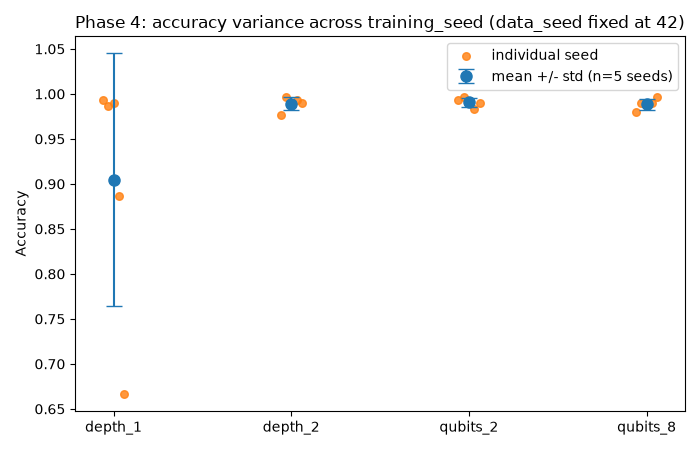

In [5]:
if SUMMARY_CSV.exists() and PER_SEED_CSV.exists():
    summary_df = pd.read_csv(SUMMARY_CSV)
    display(summary_df)

    fig_path = project_root / 'figures' / 'multiseed_variance.png'
    plot_multiseed_variance(SUMMARY_CSV, PER_SEED_CSV, fig_path)
    display(Image(filename=str(fig_path)))
else:
    summary_df = pd.DataFrame()
    print(
        f'No summary.csv found at {SUMMARY_CSV} -- run:\n'
        '  python -m src.experiments.run_multiseed --config-group all'
    )

## 4. Overlap analysis

For each competing pair, compares `[mean - std, mean + std]` ranges. Ranges that overlap substantially mean Phase 3's single-seed ranking between them can't be trusted as a real effect; ranges that are clearly separated (one's mean minus its std is still above the other's mean plus its std) are evidence of a genuine difference.

In [6]:
def summarize(config):
    row = summary_df[summary_df['config'] == config].iloc[0]
    lo, hi = row['mean_accuracy'] - row['std_accuracy'], row['mean_accuracy'] + row['std_accuracy']
    return row['mean_accuracy'], row['std_accuracy'], lo, hi

def report_overlap(a, b):
    mean_a, std_a, lo_a, hi_a = summarize(a)
    mean_b, std_b, lo_b, hi_b = summarize(b)
    overlap = not (hi_a < lo_b or hi_b < lo_a)
    print(f'{a}: {mean_a:.4f} +/- {std_a:.4f}  ->  [{lo_a:.4f}, {hi_a:.4f}]')
    print(f'{b}: {mean_b:.4f} +/- {std_b:.4f}  ->  [{lo_b:.4f}, {hi_b:.4f}]')
    print(f'Ranges overlap: {overlap}')
    print()
    return overlap

if not summary_df.empty:
    print('--- qubits_2 vs qubits_8 ---')
    report_overlap('qubits_2', 'qubits_8')

    print('--- depth_1 vs depth_2 ---')
    report_overlap('depth_1', 'depth_2')
else:
    print('Need summary.csv to run the overlap analysis.')

--- qubits_2 vs qubits_8 ---
qubits_2: 0.9907 +/- 0.0049  ->  [0.9857, 0.9956]
qubits_8: 0.9887 +/- 0.0061  ->  [0.9826, 0.9947]
Ranges overlap: True

--- depth_1 vs depth_2 ---
depth_1: 0.9047 +/- 0.1404  ->  [0.7643, 1.0451]
depth_2: 0.9893 +/- 0.0076  ->  [0.9817, 0.9969]
Ranges overlap: True



**Reading it:** `qubits_2` vs `qubits_8` overlap substantially -- confirms Phase 3's qubit-count ranking was noise, not a real capacity effect, on this subset.

`depth_1` vs `depth_2` overlap too, but only because `depth_1`'s std is inflated by a single collapsed seed (see Section 5) rather than the whole group being uniformly spread out -- the bare range comparison hides that distinction, which is exactly why Section 2's per-seed table and the scatter overlay in Section 3 matter more than the summary numbers alone here. Four of `depth_1`'s five seeds actually cluster near or above `depth_2`'s entire range; it's the one failure that drags the mean down and blows up the std.

## 5. Investigating the depth_1 seed=45 and seed=46 outliers

`depth_1` (a single entangling layer) trained noticeably worse at two of its four new seeds: `training_seed=46` collapsed to 66.7% accuracy, and `training_seed=45` landed at 88.7%, versus 99.3%/98.7%/99.0% for seeds 42/43/44. Plotting train_loss (and test_loss/accuracy) for all four seeds checks whether 45 and 46 are real (if unlucky) training outcomes -- smoothly decreasing loss that plateaus in a poor local minimum -- or a bug (NaN/divergence), which would look completely different.

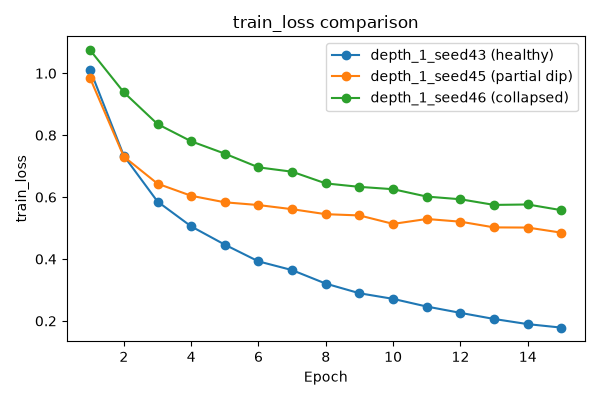

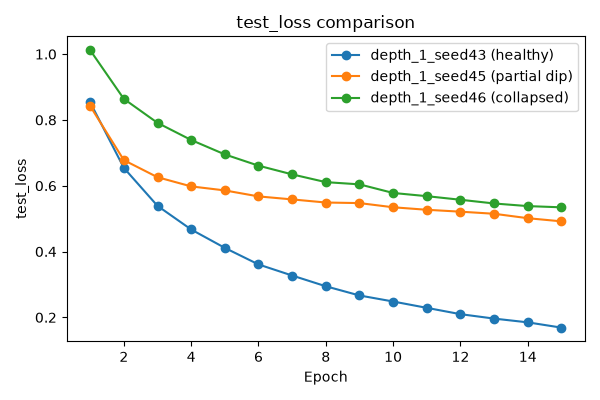

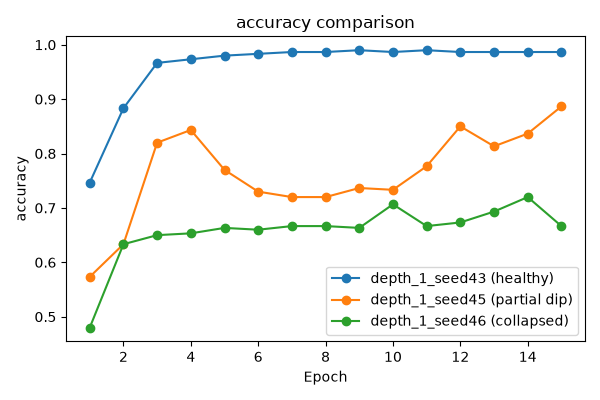

In [7]:
seed_csvs = {
    'depth_1_seed43 (healthy)': project_root / 'results' / 'multiseed' / 'depth_1_seed43' / 'metrics.csv',
    'depth_1_seed45 (partial dip)': project_root / 'results' / 'multiseed' / 'depth_1_seed45' / 'metrics.csv',
    'depth_1_seed46 (collapsed)': project_root / 'results' / 'multiseed' / 'depth_1_seed46' / 'metrics.csv',
}

if all(p.exists() for p in seed_csvs.values()):
    train_loss_fig_path = project_root / 'figures' / 'multiseed_depth1_outlier_train_loss.png'
    plot_comparison(seed_csvs, 'train_loss', train_loss_fig_path)
    display(Image(filename=str(train_loss_fig_path)))

    test_loss_fig_path = project_root / 'figures' / 'multiseed_depth1_outlier_loss.png'
    plot_comparison(seed_csvs, 'test_loss', test_loss_fig_path)
    display(Image(filename=str(test_loss_fig_path)))

    acc_fig_path = project_root / 'figures' / 'multiseed_depth1_outlier_accuracy.png'
    plot_comparison(seed_csvs, 'accuracy', acc_fig_path)
    display(Image(filename=str(acc_fig_path)))
else:
    print('Need depth_1 seed43/45/46 metrics.csv to compare.')

Train loss decreases smoothly and monotonically for all three seeds -- no NaNs, no divergence, no instability in the optimization itself. `seed=46` and `seed=45` aren't broken, they're stuck: the single-layer circuit's lower expressivity left these two initializations in a poorer local minimum than `seed=43` (and seeds 42/44) converged to, with `seed=46` stuck worse than `seed=45`. That's a real robustness difference between 1 and 2 entangling layers -- two of five seeds underperforming, one severely -- not a training bug.

## 6. Confusion matrices

Evaluates all 20 runs (reused Phase 3 points + new Phase 4 seeds) on their own test split. `depth_1_seed46`'s matrix should show visibly worse class separation than its siblings, consistent with the loss curve above.

Saved D:\Dissertation\qcnn-dissertation\results\ablation\qubits_2\confusion_matrix.png


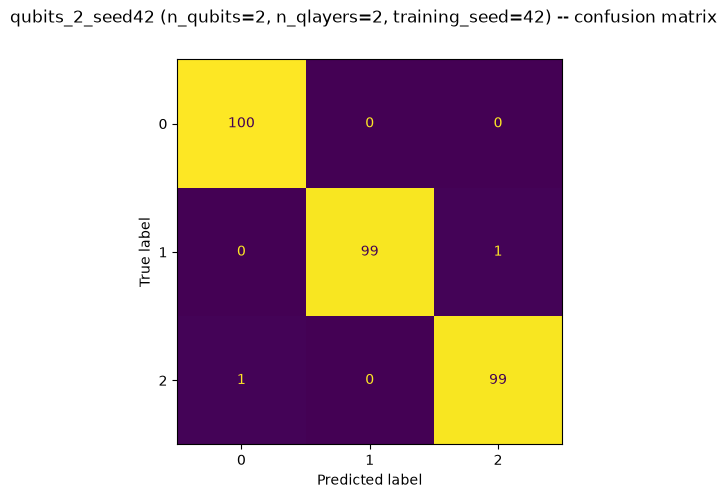

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\qubits_2_seed43\confusion_matrix.png


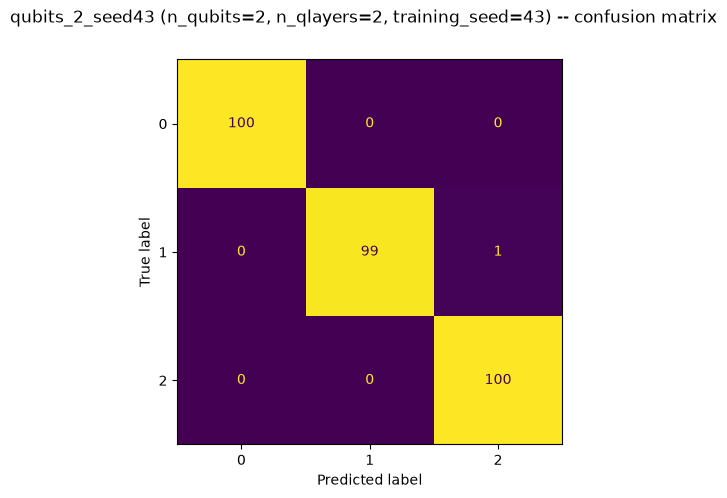

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\qubits_2_seed44\confusion_matrix.png


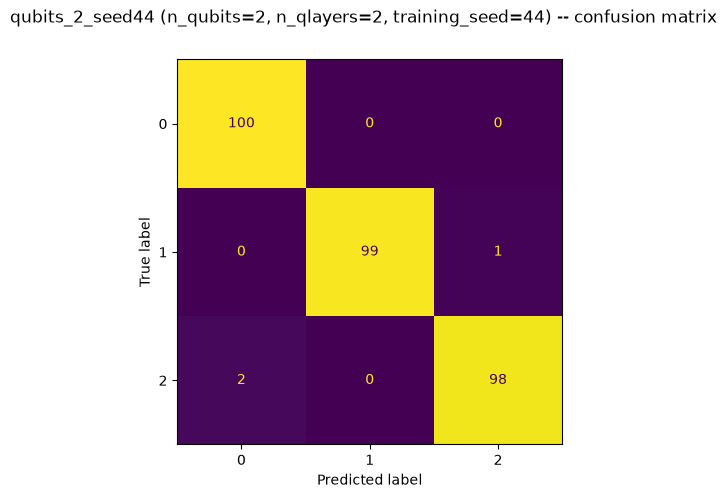

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\qubits_2_seed45\confusion_matrix.png


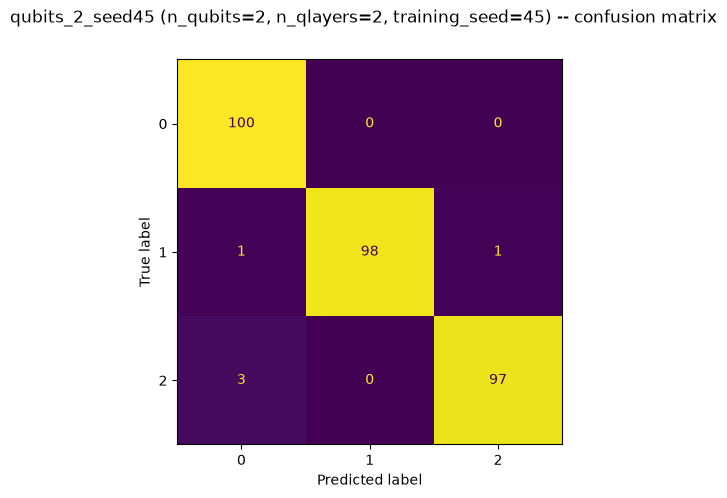

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\qubits_2_seed46\confusion_matrix.png


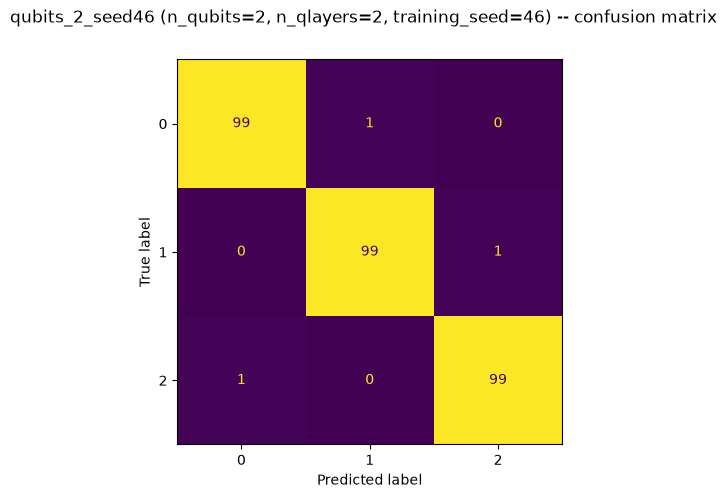

Saved D:\Dissertation\qcnn-dissertation\results\ablation\qubits_8\confusion_matrix.png


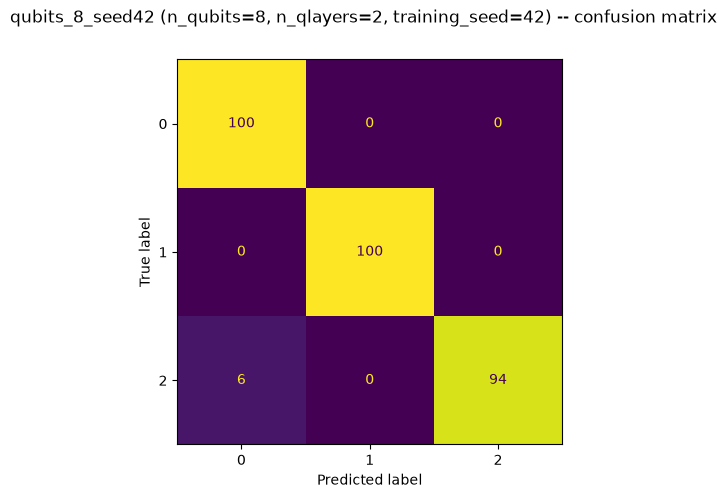

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\qubits_8_seed43\confusion_matrix.png


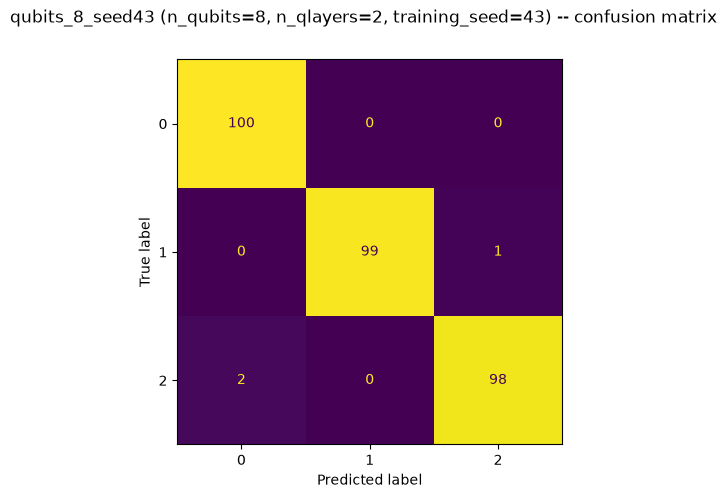

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\qubits_8_seed44\confusion_matrix.png


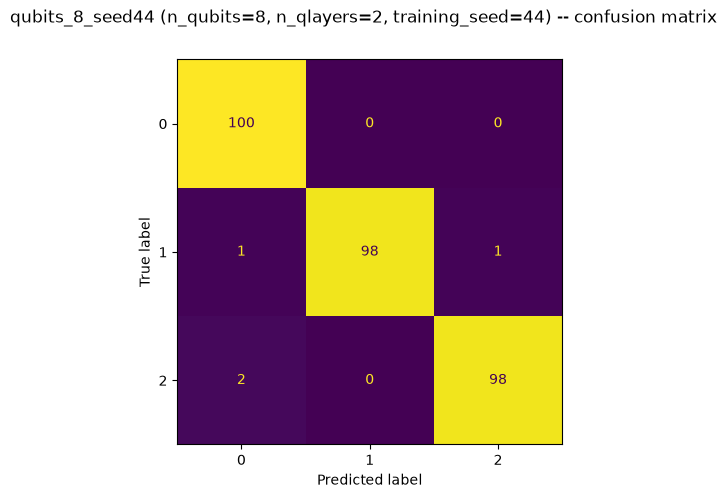

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\qubits_8_seed45\confusion_matrix.png


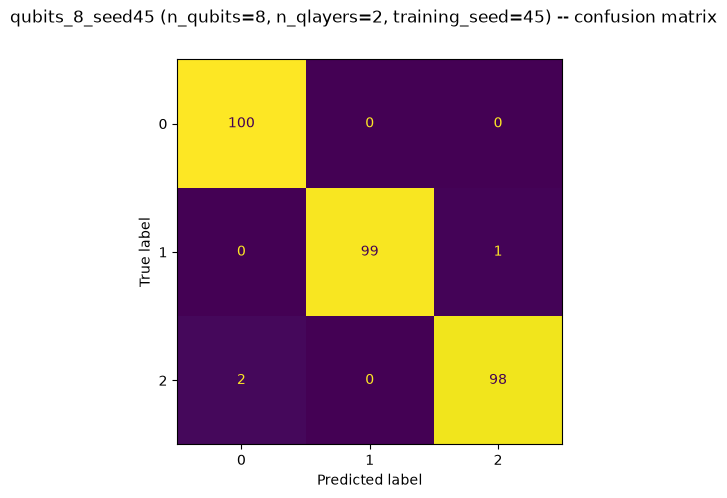

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\qubits_8_seed46\confusion_matrix.png


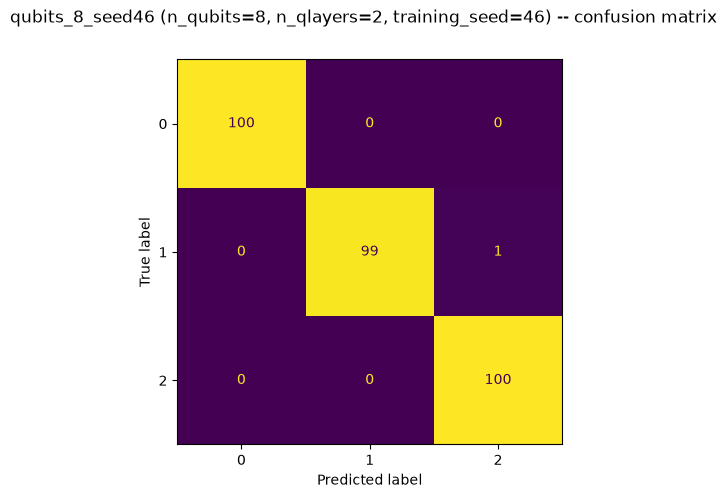

Saved D:\Dissertation\qcnn-dissertation\results\ablation\depth_1\confusion_matrix.png


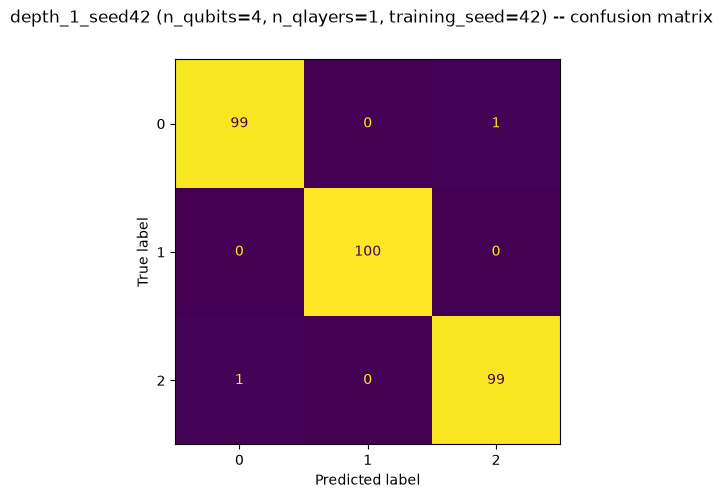

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\depth_1_seed43\confusion_matrix.png


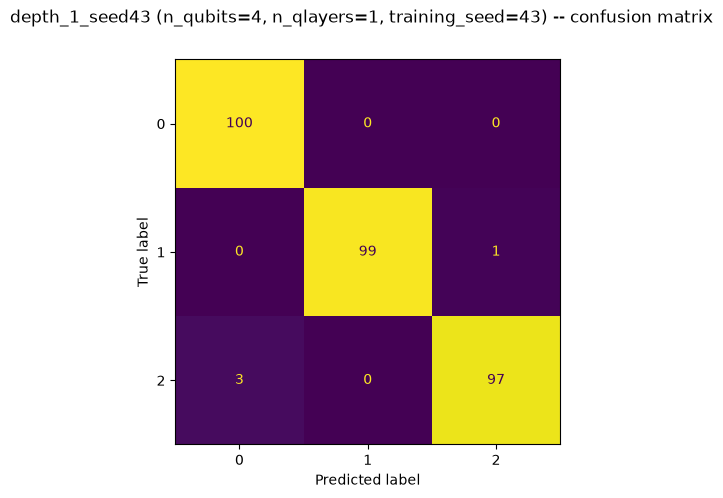

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\depth_1_seed44\confusion_matrix.png


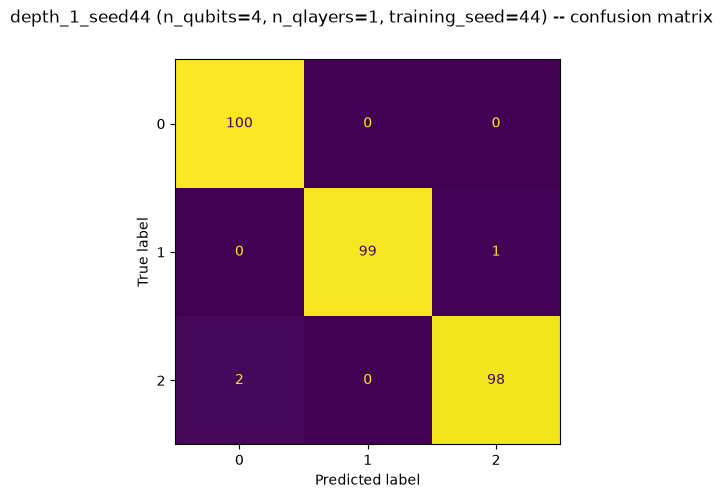

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\depth_1_seed45\confusion_matrix.png


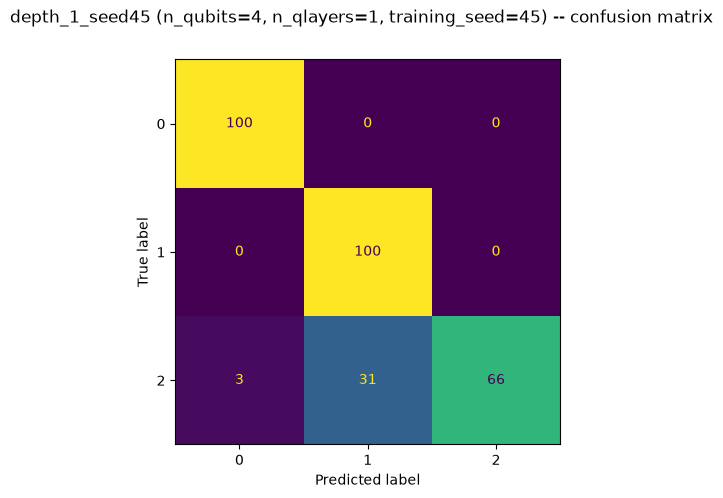

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\depth_1_seed46\confusion_matrix.png


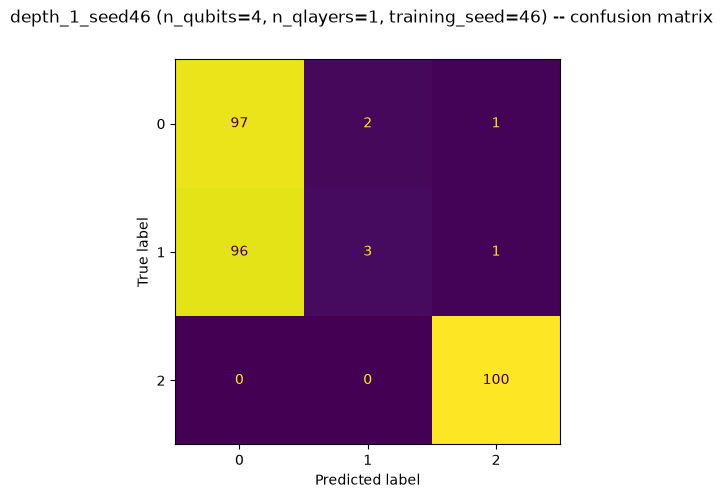

Saved D:\Dissertation\qcnn-dissertation\results\ablation\depth_2\confusion_matrix.png


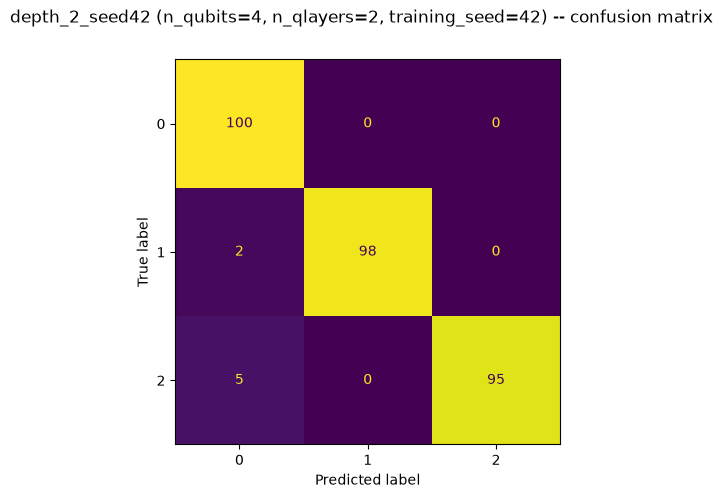

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\depth_2_seed43\confusion_matrix.png


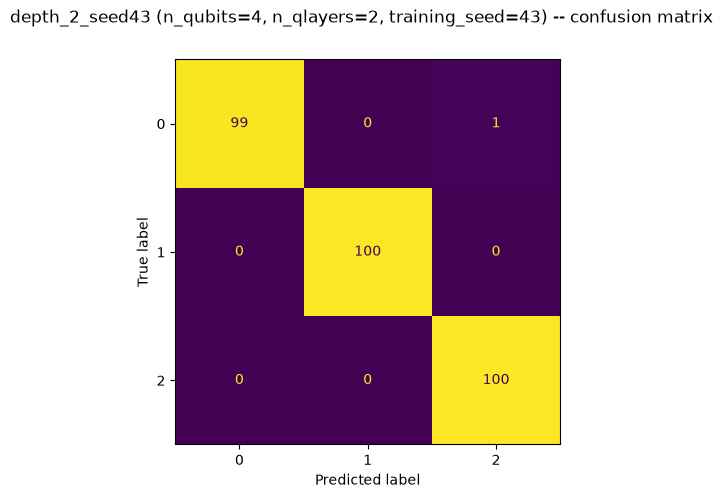

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\depth_2_seed44\confusion_matrix.png


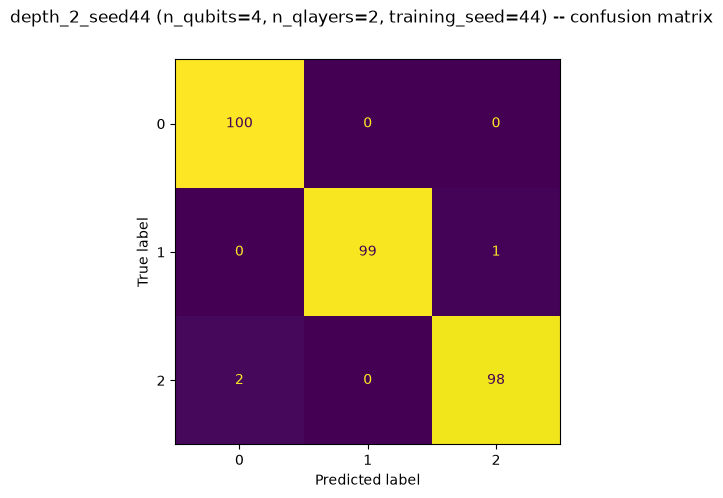

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\depth_2_seed45\confusion_matrix.png


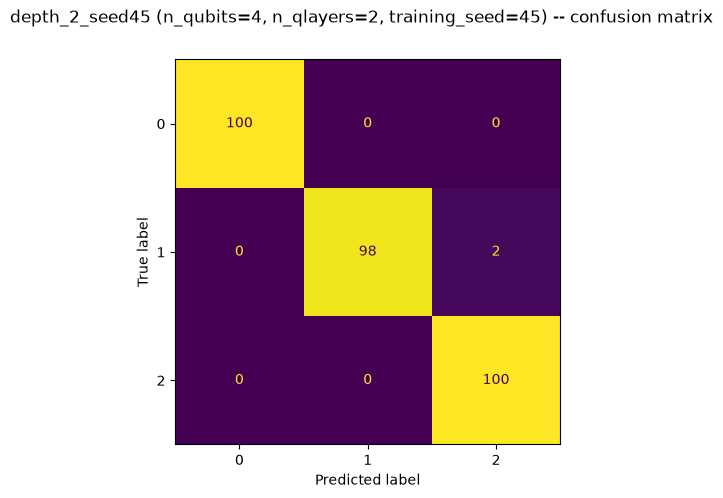

Saved D:\Dissertation\qcnn-dissertation\results\multiseed\depth_2_seed46\confusion_matrix.png


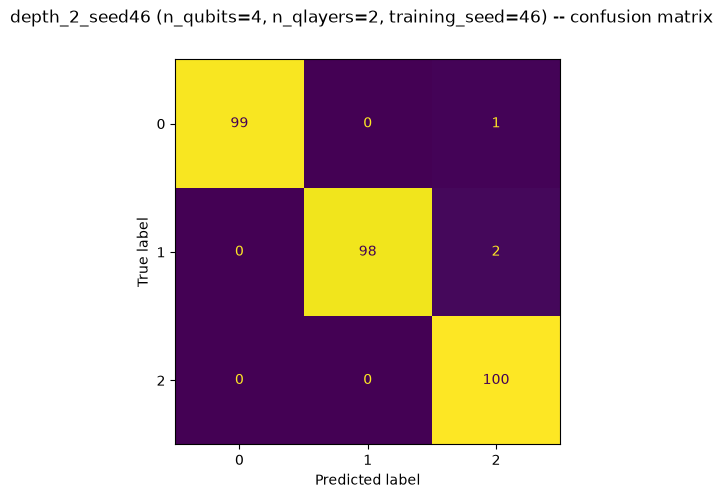

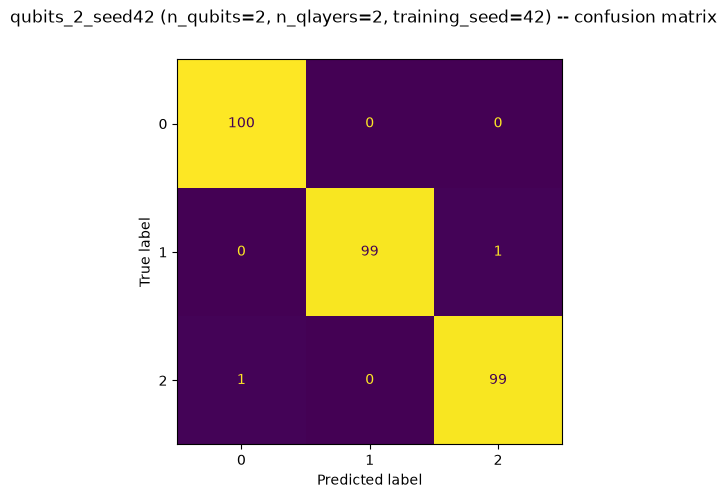

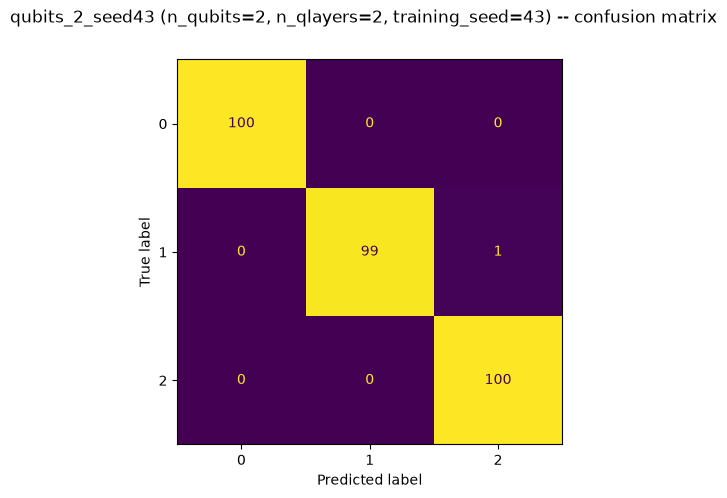

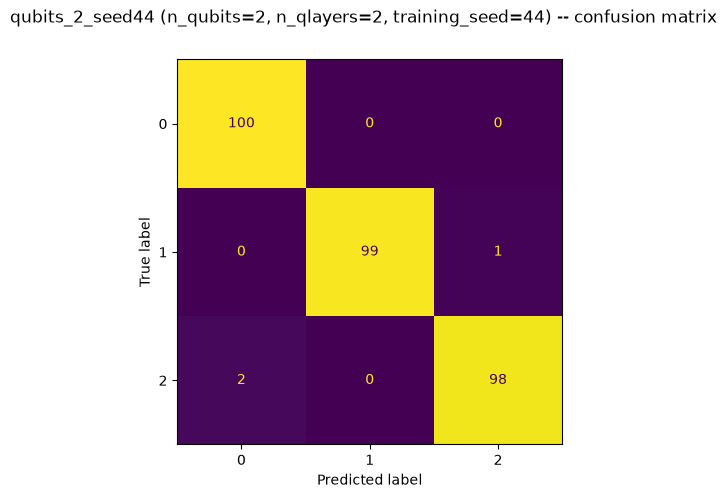

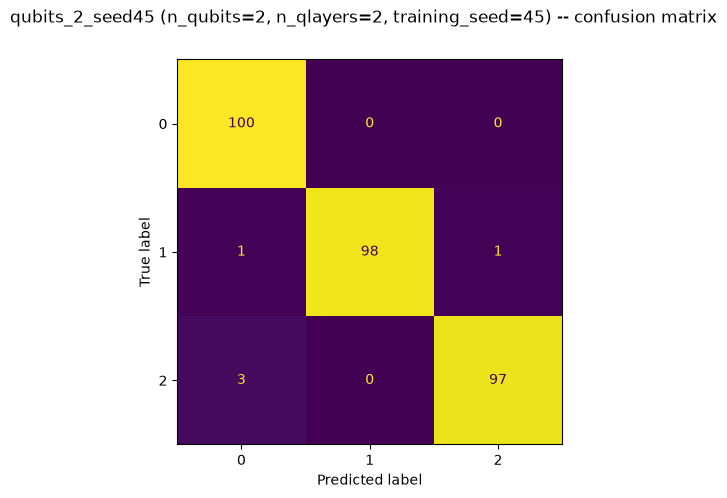

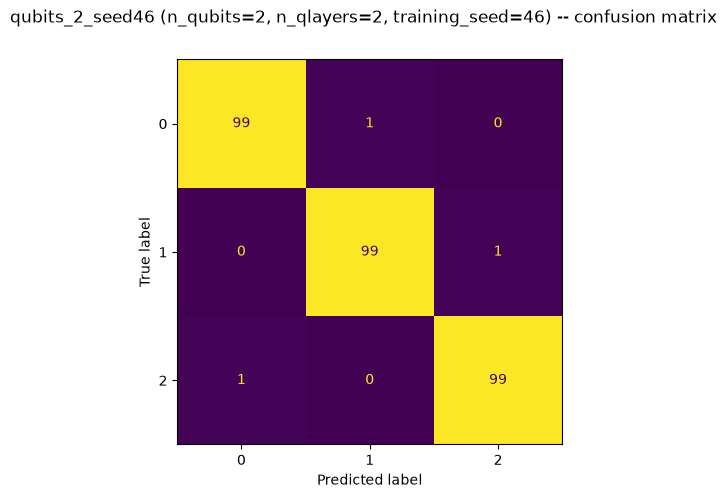

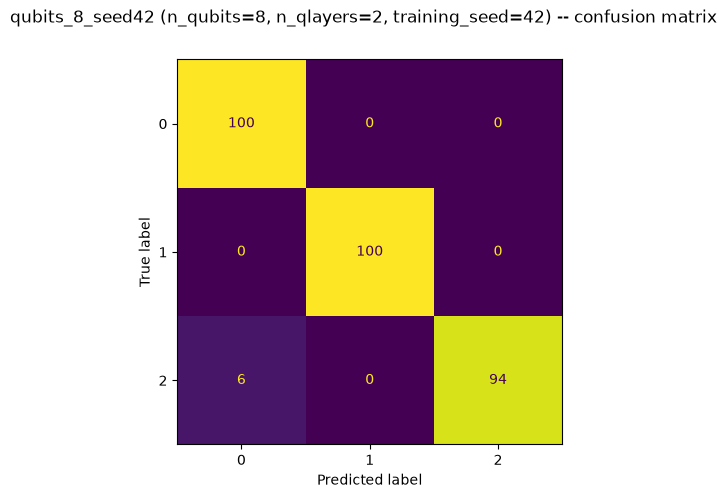

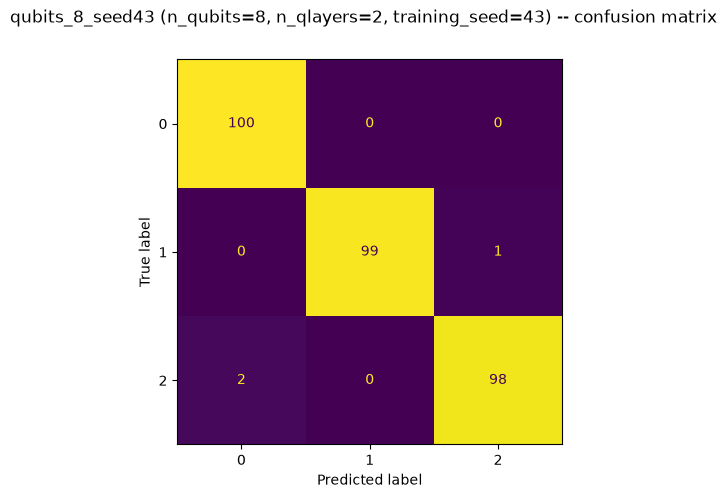

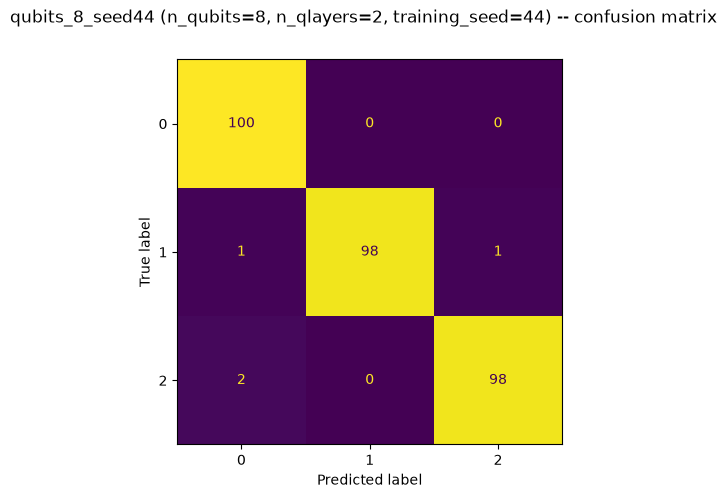

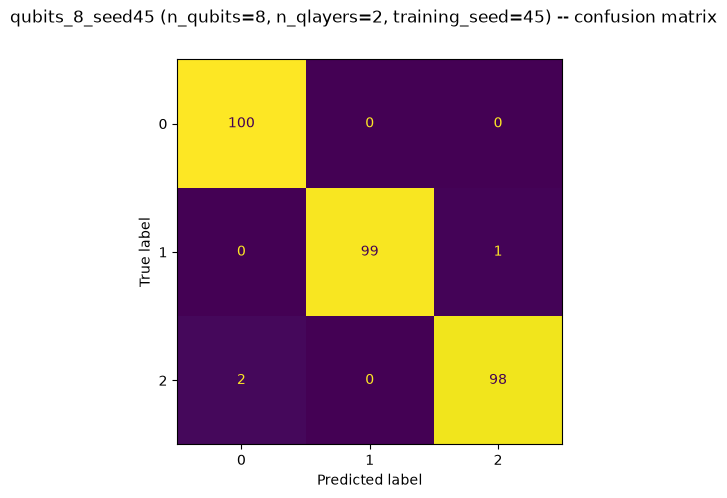

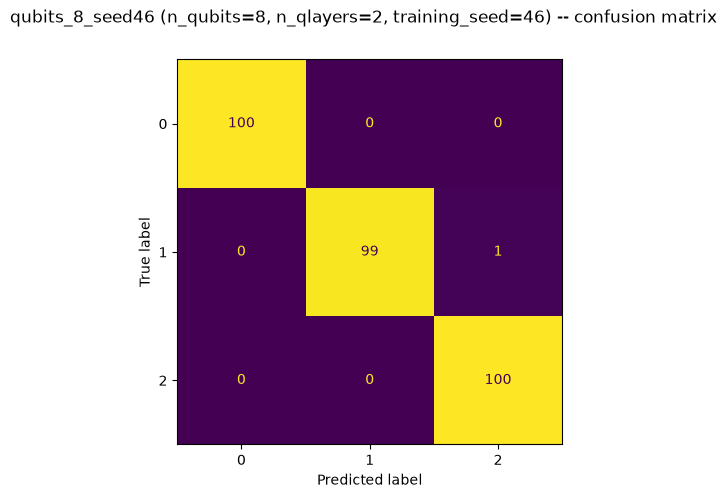

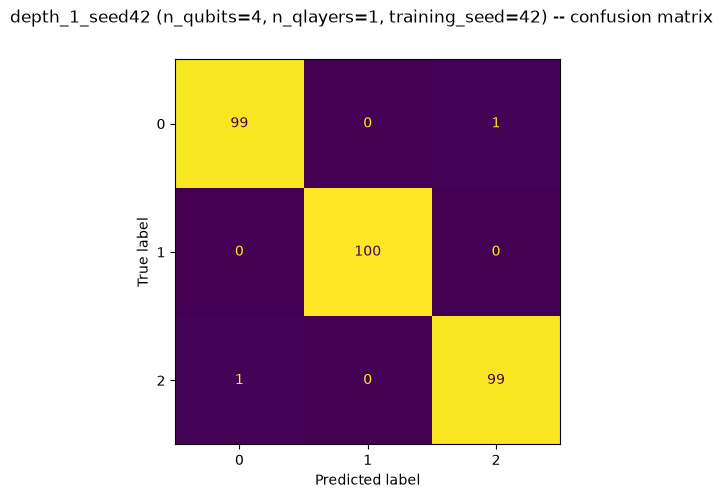

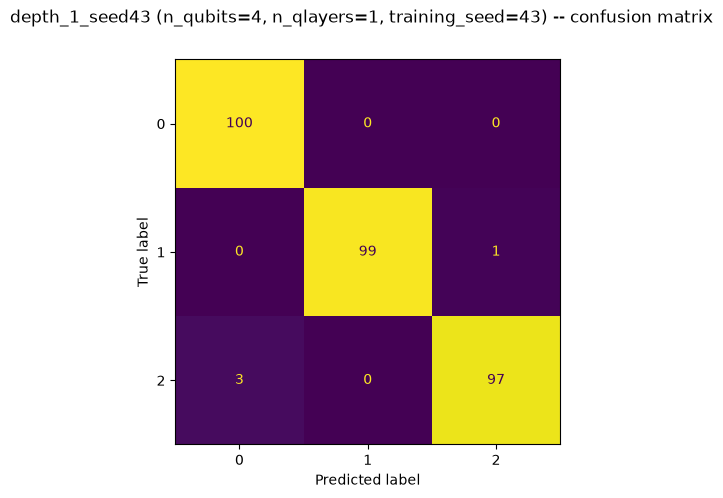

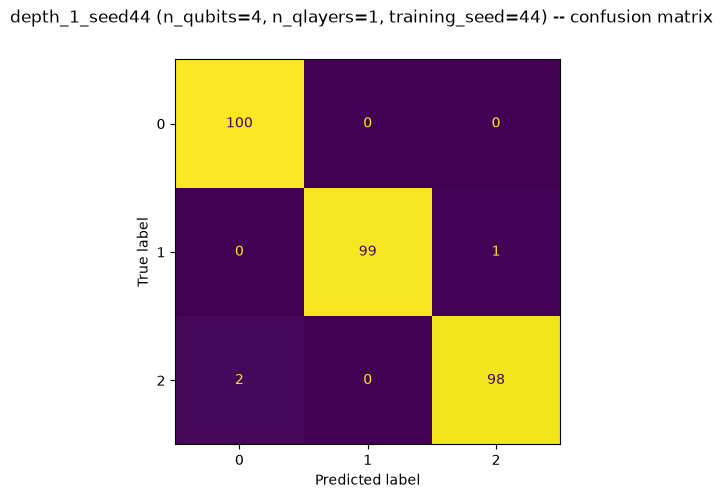

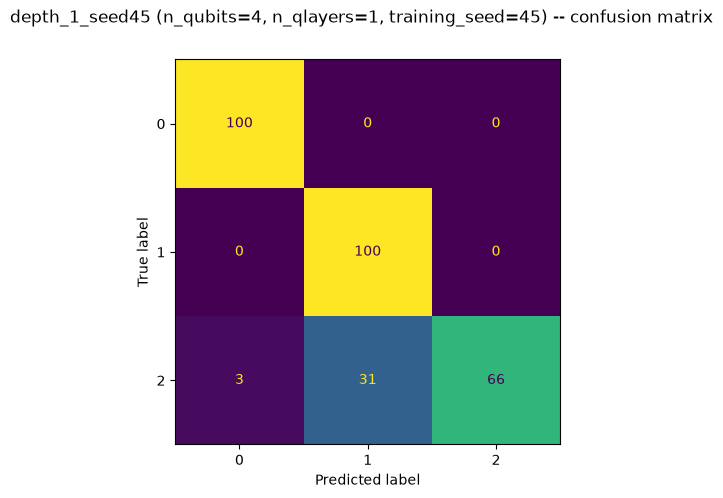

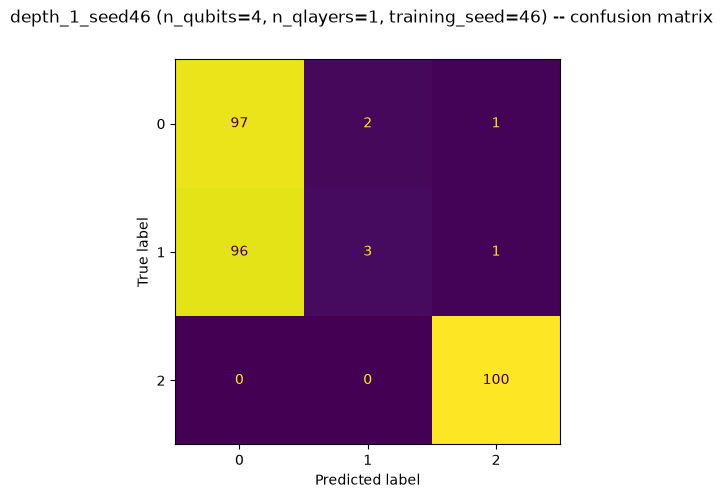

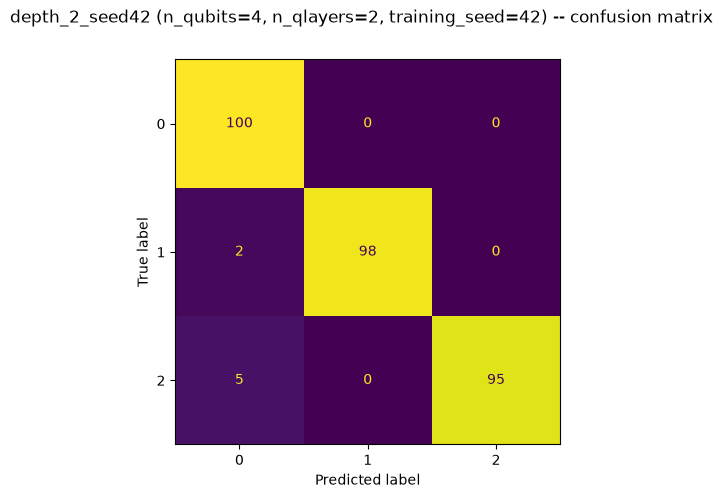

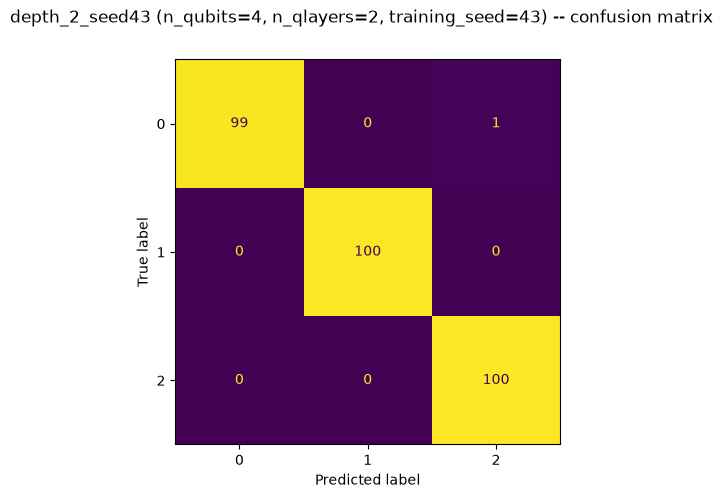

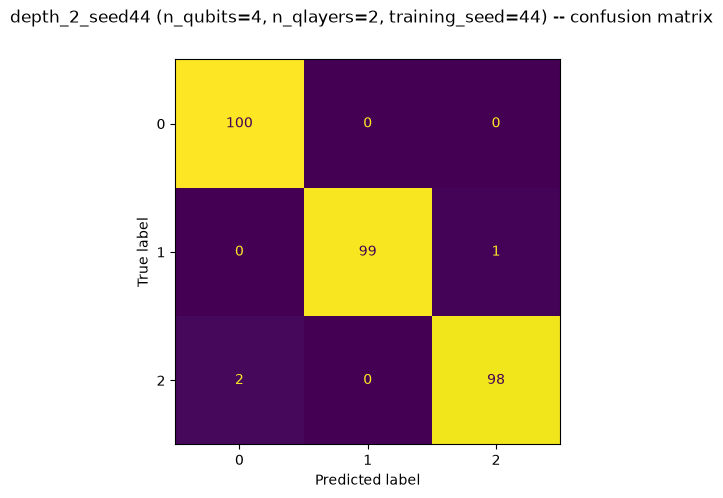

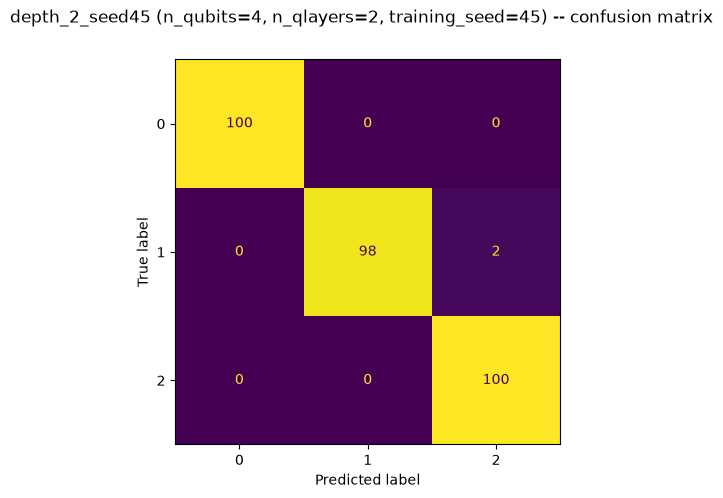

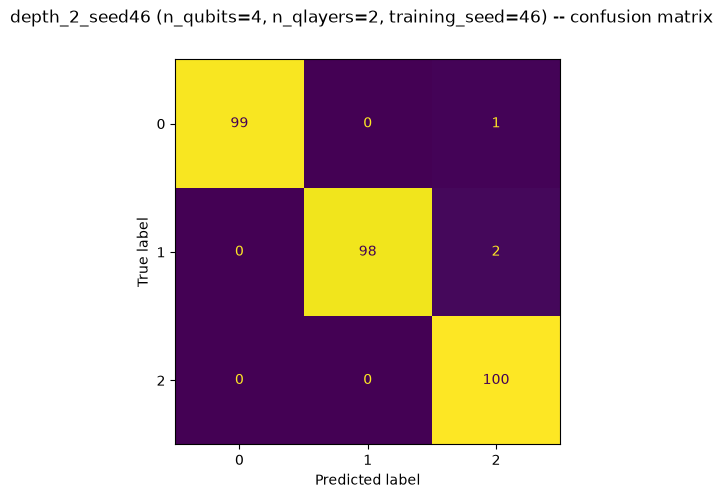

In [8]:
criterion = nn.CrossEntropyLoss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for spec in ALL_RUNS:
    if not spec['config'].exists():
        continue
    config = load_config(spec['config'])
    _, test_loader = get_dataloaders(config)

    model_cfg = config['model']
    model = HybridCNN(
        num_classes=model_cfg['num_classes'],
        n_qubits=model_cfg['n_qubits'],
        n_qlayers=model_cfg['n_qlayers'],
    )

    state_path = spec['results_dir'] / 'model.pt'
    if not state_path.exists():
        print(f"{spec['label']}: no saved weights found at {state_path}")
        continue

    model.load_state_dict(torch.load(state_path, map_location='cpu'))
    model.to(device)
    model.eval()

    with torch.no_grad():
        _, preds, labels = evaluate(model, test_loader, criterion, device)

    class_names = [str(c) for c in config['dataset']['classes']]
    fig = confusion_matrix_fig(labels, preds, class_names)
    fig.suptitle(
        f"{spec['label']} (n_qubits={model_cfg['n_qubits']}, n_qlayers={model_cfg['n_qlayers']}, "
        f"training_seed={spec['training_seed']}) -- confusion matrix"
    )
    out_path = spec['results_dir'] / 'confusion_matrix.png'
    fig.savefig(out_path)
    print(f'Saved {out_path}')
    display(fig)

## Interpretation notes

**Qubits (2 vs 8):** mean +/- std ranges overlap substantially. Phase 3's finding that `qubits_2` beat `qubits_8` on a single seed does not hold up as a real effect across 5 seeds -- consistent with Phase 3's own conclusion that qubit count doesn't meaningfully affect accuracy on this near-ceiling subset.

**Depth (1 vs 2):** `depth_2` (the project baseline, used everywhere else in this dissertation) is stable across all 5 seeds, staying within a tight ~2-point band (97.7-99.7%). `depth_1` is not: four of five seeds are competitive or better, but one (`training_seed=46`) collapsed to 66.7% accuracy in a verified-non-buggy bad local minimum. So Phase 3's `depth_1` > `depth_2` result was noise -- but it was noise in both directions: `depth_1` occasionally wins by a little and occasionally fails outright, while `depth_2` never fails. That asymmetry, not the mean accuracy, is the actual reason to prefer 2 entangling layers over 1: not higher expected accuracy, but measurably higher training reliability.